In [4]:
import jax
import jax.numpy as jnp
import flax.nnx as nnx
import netket as nk
import netket.experimental as nkx
import sys
sys.path.append('..')
from NES_VMC import NESTotalAnsatz, create_machine,\
        ha,SingleStateAnsatz,create_single_machine,\
        create_machine_matrix,Ham_psi,Ham_Psi,NES_loss_energy,nes_vmc_gradient,hi,E_fcis,\
        NESFermionHopRule,compute_qgt,sampler_info,NESFermionHopRule
import optax
from typing import Callable
from functools import partial
from jax.flatten_util import ravel_pytree
import time
import logging
# ========== 你原有全局参数（直接复用） ==========
# 单系统希尔伯特空间
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals=2,
    s=1/2,
    n_fermions_per_spin=(1,1),
)
K = 4  # NES 扩展副本数
hi_ext = hi ** K  # 扩展希尔伯特空间
SINGLE_SIZE = hi.size  # 单个子系统维度 = 4
single_edges = ((0, 1), (2, 3))  # 费米子跃迁边
g = nk.graph.Graph(edges=single_edges)
single_rule = nk.sampler.rules.FermionHopRule(hi, graph=g)
tensor_rule = nk.sampler.rules.TensorRule(hi_ext, [single_rule] * K)

total_ansatz = NESTotalAnsatz(4,K,12,rngs=nnx.Rngs(11))
total_machine, total_graphdef,total_params = create_machine(total_ansatz)
total_matrix_machine, total_graphdef,total_params = create_machine_matrix(total_ansatz)

single_machine_list = []
for ansatz in total_ansatz.single_ansatz_list:
    m, g, p = create_single_machine(ansatz)
    single_machine_list.append(m)

In [6]:
import logging
# 日志配置
logger = logging.getLogger('NES_VMC_K4')
logger.setLevel(logging.INFO)
# 阻止日志向上传播
logger.propagate = False
# 清除所有旧handler，防止重复打印
logger.handlers.clear()

# 自定义日志格式：只打印内容，不带等级、logger名
simple_formatter = logging.Formatter("%(message)s", datefmt="%H:%M:%S")

# 1. 文件输出处理器
file_handler = logging.FileHandler("nes_vmc_0616_K4.log", mode="w", encoding="utf-8")
file_handler.setFormatter(simple_formatter)
file_handler.setLevel(logging.INFO)
logger.addHandler(file_handler)

console_handler = logging.StreamHandler()
console_handler.setFormatter(simple_formatter)
console_handler.setLevel(logging.INFO)
logger.addHandler(console_handler)

print('库导入完成')

库导入完成


In [10]:
N_CHAINS = 16
N_WARMUP = 100
N_SAMPLES_PER_CHAIN = 200
SWEEP_SIZE = 30
N_ITER =40
SINGLE_SIZE = hi.size  # 单个子系统维度 = 4
Natural_Grad = False


total_ansatz = NESTotalAnsatz(4,K,12,rngs=nnx.Rngs(11))
total_machine, total_graphdef,total_params = create_machine(total_ansatz)
total_matrix_machine, total_graphdef,total_params = create_machine_matrix(total_ansatz)

single_machine_list = []
for ansatz in total_ansatz.single_ansatz_list:
    m, g, p = create_single_machine(ansatz)
    single_machine_list.append(m)
    
    

optimizer = optax.sgd(learning_rate=0.01)
opt_state = optimizer.init(total_params)

ext_edges = []
for k in range(K):
    offset = k * SINGLE_SIZE
    for (i, j) in single_edges:
        ext_edges.append((i + offset, j + offset))
ext_edges = jnp.array(ext_edges)  # 转为jax数组（关键修复）

nes_rule = NESFermionHopRule(edges=ext_edges, K=K, single_size=SINGLE_SIZE)
nes_sampler = nk.sampler.MetropolisSampler(
    hilbert=hi_ext,
    rule=nes_rule,
    n_chains=16,
    sweep_size=20
)


# 采样器状态初始化（替代原 init_sampler_state）
sampler_rng = jax.random.PRNGKey(21)
sampler_state = nes_sampler.init_state(total_machine, total_params, sampler_rng)

# ==================== 训练循环（仅替换采样部分） ====================
logger.info("\n" + "="*60)
logger.info("开始多链 NES-VMC 训练 (NetKet 自定义采样器 + 朴素梯度下降)")
logger.info("="*60)
logger.info(f"基态能量={E_fcis[0]:.8f} Ha| 第一激发态能量={E_fcis[1]:.8f} Ha| 第二激发态能量={E_fcis[2]:.8f} Ha| 第三激发态能量={E_fcis[3]:.8f} Ha")

history = {
    'step': [],
    'energy_0st': [],
    'energy_1st': [],
    'energy_2st': [],
    'energy_3st': [],
    'energy_std': [],
    'loss': [],
    'params': [],
    'E_Lmatrix':[],
    'natural_grad':[],
    'grad_flat':[],
    'samples':[],
    'log_Psi':[],
    'log_M':[],
    'log_Psi_mean':[],
    'log_Psi_min':[],
    'log_Psi_max':[],
    'grad_norm_before':[],
    'grad_norm_after':[],
}

start_time = time.time()
for step in range(N_ITER):
    # 2. 正式采样
    samples_raw, sampler_state = nes_sampler.sample(
        machine=total_machine, parameters=total_params, 
        state=sampler_state, chain_length=N_SAMPLES_PER_CHAIN
    )
        # 3. 维度重塑，适配梯度函数输入
    samples = samples_raw.reshape(-1, hi_ext.size)
    x_batch = samples.reshape(-1, K, 4)
    # 3. 计算能量和自然梯度（逻辑和原代码一致）
    grad, loss_mean, E_L_mean = nes_vmc_gradient(ha=ha,
                                                 total_matrix_machine=total_matrix_machine,
                                                 total_machine=total_machine,
                                                 single_machine_list=single_machine_list,
                                                 total_params=total_params,
                                                 x_batch=samples.reshape(-1,K,4))
    #grad = jax.tree_util.tree_map(lambda x: x * 2, grad)
    grad_flat , grad_unravel_fn = ravel_pytree(grad)
    grad_norm_before = jnp.linalg.norm(grad_flat)
    
    if Natural_Grad == True:

        qgt_reg, unravel_fn = compute_qgt(total_machine, total_params, samples.reshape(-1,K,4), diag_shift=0.01)
        natural_grad_flat = jnp.linalg.solve(qgt_reg, grad_flat)
        natural_grad = grad_unravel_fn(natural_grad_flat)
        grad = natural_grad
        
    # 4. 更新参数
    updates, opt_state = optimizer.update(grad, opt_state, total_params)
    total_params = optax.apply_updates(total_params, updates)

    log_Psi_batch = total_machine(total_params, samples.reshape(-1,K,4))
    eig_vals, eig_vecs = jnp.linalg.eigh(E_L_mean)
    
    grad_flat , grad_unravel_fn = ravel_pytree(grad)
    grad_norm_after = jnp.linalg.norm(grad_flat)
    
    
    history['step'].append(step)
    history['E_Lmatrix'].append(E_L_mean)
    history['samples'].append(samples)
    history['loss'].append(loss_mean)
    history['log_Psi_mean'].append(log_Psi_batch.mean())
    history['log_Psi_min'].append(log_Psi_batch.min())
    history['log_Psi_max'].append(log_Psi_batch.max())
    history['grad_norm_before'].append(grad_norm_before)
    history['grad_norm_after'].append(grad_norm_after)
    history['energy_0st'].append(eig_vals[0])
    history['energy_1st'].append(eig_vals[1])
    history['energy_2st'].append(eig_vals[2])
    history['energy_3st'].append(eig_vals[3])
    history['params'].append(total_params)
    # 5. 记录历史
    if step % 10 == 0 or step == N_ITER - 1:
        # --------------------- 【NES-VMC 监控模板】直接用 ---------------------
        # 1. 监控 log_Psi
        logger.info(f"log_Psi: mean={log_Psi_batch.mean():.3f} | min={log_Psi_batch.min():.3f} | max={log_Psi_batch.max():.3f}")
        # 2. 监控梯度范数
        logger.info(f"grad norm = {grad_norm:.4f}|grad norm after = {grad_norm_after:.4f}")
        logger.info(f"Step {step:3d} | Loss: {loss_mean}|0st能量={eig_vals[0]:.8f} Ha｜1st能量={eig_vals[1]:.8f} Ha｜2st能量={eig_vals[2]:.8f} Ha｜3st能量={eig_vals[3]:.8f} Ha")
        # print(f'grad={grad_flat[30:31]}')
        logger.info('#-----------------------------------------#')


end_time = time.time()
print(f"训练耗时：{end_time - start_time:.2f} 秒")
# 最终结果
print("\n" + "="*60)
print(f"训练完成!")
print("="*60)


开始多链 NES-VMC 训练 (NetKet 自定义采样器 + 朴素梯度下降)
基态能量=-1.01546825 Ha| 第一激发态能量=-0.87542794 Ha| 第二激发态能量=-0.42938376 Ha| 第三激发态能量=-0.26922131 Ha
log_Psi: mean=0.490-0.609j | min=-36.671-2.038j | max=0.525+0.766j
grad norm = 0.0000|grad norm after = 0.0141
Step   0 | Loss: -2.5891712445550525|0st能量=-1.69008899 Ha｜1st能量=-1.23782404 Ha｜2st能量=-0.04772049 Ha｜3st能量=0.38646228 Ha
#-----------------------------------------#
log_Psi: mean=0.525-0.609j | min=0.525-2.376j | max=0.525+0.766j
grad norm = 0.0000|grad norm after = 0.0000
Step  10 | Loss: -2.5895012541466076|0st能量=-1.68943249 Ha｜1st能量=-1.23837185 Ha｜2st能量=-0.04839203 Ha｜3st能量=0.38669511 Ha
#-----------------------------------------#
log_Psi: mean=0.525-0.609j | min=0.525-2.376j | max=0.525+0.766j
grad norm = 0.0000|grad norm after = 0.0000
Step  20 | Loss: -2.5895012541466076|0st能量=-1.68943249 Ha｜1st能量=-1.23837185 Ha｜2st能量=-0.04839203 Ha｜3st能量=0.38669511 Ha
#-----------------------------------------#
log_Psi: mean=0.525-0.609j | min=0.525-2.376j

训练耗时：22.95 秒

训练完成!


$$
\begin{align*}
\Psi(\mathbf{x})^{-1}\hat{\mathcal{H}}\Psi(\mathbf{x})
&= \mathrm{Tr}\left[ \Psi^{-1}(\mathbf{x})\hat{H}\Psi(\mathbf{x}) \right]
\end{align*}
$$

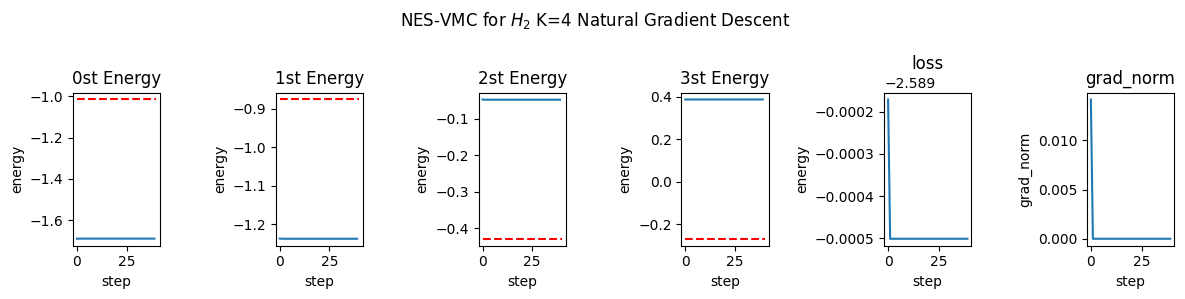

In [14]:
import matplotlib.pyplot as plt

# 创建 2行1列 的子图
fig, axs = plt.subplots(1, 6, figsize=(12, 3))
fig.suptitle('NES-VMC for $H_2$ K=4 Natural Gradient Descent')
# 第一个子图
axs[0].plot(history['energy_0st'])
axs[0].hlines(E_fcis[0],0,len(history['energy_0st']),linestyle='--',color='red')
axs[0].set_title('0st Energy')
axs[0].set_ylabel('energy')
axs[0].set_xlabel('step')

axs[1].plot(history['energy_1st'])
axs[1].hlines(E_fcis[1],0,len(history['energy_1st']),linestyle='--',color='red')
axs[1].set_title('1st Energy')
axs[1].set_ylabel('energy')
axs[1].set_xlabel('step')

axs[2].plot(history['energy_2st'])
axs[2].hlines(E_fcis[2],0,len(history['energy_2st']),linestyle='--',color='red')
axs[2].set_title('2st Energy')
axs[2].set_ylabel('energy')
axs[2].set_xlabel('step')

axs[3].plot(history['energy_3st'])
axs[3].hlines(E_fcis[3],0,len(history['energy_3st']),linestyle='--',color='red')
axs[3].set_title('3st Energy')
axs[3].set_ylabel('energy')
axs[3].set_xlabel('step')

# 第二个子图
axs[4].plot(history['loss'])
axs[4].set_title('loss')
axs[4].set_xlabel('step')
axs[4].set_ylabel('energy')

# 第三个子图
axs[5].plot(history['grad_norm_after'])
axs[5].set_title('grad_norm')
axs[5].set_xlabel('step')
axs[5].set_ylabel('grad_norm')

plt.tight_layout()  # 自动调整间距
plt.show()

In [18]:
import jax
import jax.numpy as jnp

jnp.log(-1+2j)
jnp.log(-1)

Array(nan, dtype=float64, weak_type=True)